# Praktikum IF3270 Pembelajaran Mesin
## Customer Segmentation Classification — Loan Status Prediction

**Nama Anggota:**
- 10122062 — Albi Arrizkya Putra
- 10123053 — Timothy Niels Ruslim

**Kelas: 1**

---

## 0. Import Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Ensemble models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier
)

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

# TODO: Tambahkan import lainnya sesuai kebutuhan

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [ ]:
from google.colab import files

# Load dataset
try:
  train_df = pd.read_csv('train.csv')
  test_df  = pd.read_csv('test.csv')
except FileNotFoundError:
  print("Upload file:")
  uploaded = files.upload()
  train_df = pd.read_csv('train.csv')
  test_df  = pd.read_csv('test.csv')
except Exception as e:
  print("Upload file:")
  uploaded = files.upload()
  train_df = pd.read_csv('train.csv')
  test_df  = pd.read_csv('test.csv')

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (36000, 13)
Test shape:  (9000, 12)


---
## 1. Exploratory Data Analysis (EDA)

> **Tujuan:** Memahami data secara mendalam sebelum preprocessing dan modeling.
> **Requirement:** Minimal **3 visualisasi** dengan **3 pertanyaan** (1 per visualisasi).

### 1.1 Gambaran Umum Dataset

In [ ]:
train_df.head(20)

,person_id,person_age,person_gender,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,6049,24.0,male,58914.0,2,OWN,4400.0,5.99,0.07,4.0,656,Yes,0
1,3347,23.0,female,45873.0,2,RENT,11000.0,11.01,0.24,2.0,634,Yes,0
2,17999,29.0,female,240947.0,7,MORTGAGE,10000.0,12.69,0.04,9.0,638,Yes,0
3,24989,30.0,female,96316.0,10,MORTGAGE,6000.0,13.49,0.06,8.0,682,No,0
4,23232,29.0,male,73033.0,7,MORTGAGE,8000.0,10.51,0.11,8.0,644,Yes,0
5,27929,32.0,female,90582.0,10,RENT,10000.0,7.29,0.11,7.0,561,Yes,0
6,23614,27.0,female,47750.0,3,RENT,9000.0,10.08,0.19,8.0,679,Yes,0
7,20372,34.0,male,40466.0,8,RENT,4500.0,11.01,0.11,9.0,603,Yes,0
8,35402,26.0,male,127119.0,2,MORTGAGE,4917.0,11.31,0.04,4.0,609,Yes,0
9,31459,40.0,male,40201.0,17,RENT,13775.0,12.98,0.34,14.0,560,No,1


In [ ]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_id                       36000 non-null  int64  
 1   person_age                      36000 non-null  float64
 2   person_gender                   36000 non-null  str    
 3   person_income                   36000 non-null  float64
 4   person_emp_exp                  36000 non-null  int64  
 5   person_home_ownership           36000 non-null  str    
 6   loan_amnt                       36000 non-null  float64
 7   loan_int_rate                   36000 non-null  float64
 8   loan_percent_income             36000 non-null  float64
 9   cb_person_cred_hist_length      36000 non-null  float64
 10  credit_score                    36000 non-null  int64  
 11  previous_loan_defaults_on_file  36000 non-null  str    
 12  loan_status                     36000 non-n

In [ ]:
train_df.describe(include='all')

,person_id,person_age,person_gender,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,36000.000000,36000.000000,36000,3.600000e+04,36000.000000,36000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000,36000.000000
unique,NaN,NaN,2,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,male,NaN,NaN,RENT,NaN,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,NaN,19786,NaN,NaN,18730,NaN,NaN,NaN,NaN,NaN,18263,NaN
mean,22495.468833,27.763194,NaN,8.054947e+04,5.405611,NaN,9586.962861,11.013158,0.139635,5.863444,632.649583,NaN,0.222222
std,12995.590721,6.045354,NaN,8.431697e+04,6.064240,NaN,6301.447426,2.976288,0.086949,3.878709,50.292346,NaN,0.415745
min,2.000000,20.000000,NaN,8.000000e+03,0.000000,NaN,500.000000,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,11236.750000,24.000000,NaN,4.716350e+04,1.000000,NaN,5000.000000,8.590000,0.070000,3.000000,602.000000,NaN,0.000000
50%,22467.500000,26.000000,NaN,6.708100e+04,4.000000,NaN,8000.000000,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,33754.500000,30.000000,NaN,9.626075e+04,8.000000,NaN,12235.000000,13.022500,0.190000,8.000000,670.000000,NaN,0.000000


In [ ]:
# Cek missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [ ]:
# Distribusi kelas target
print(train_df['loan_status'].value_counts())
print(train_df['loan_status'].value_counts(normalize=True).round(3))

loan_status
0    28000
1     8000
Name: count, dtype: int64
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


In [ ]:
target_variable = 'loan_status'

### 1.2 Visualisasi 1 — Distribusi Fitur Numerik

**Pertanyaan:**

Apa distribusi dari fitur-fitur numerik kita jika diberikan labelnya? Secara khusus, kita mencari

$$ P(X = x \mid Y = \text{Loan Status}). $$

Lalu, jika terlihat bentuk yang tidak normal, bagaimana distribusi dari pencilannya?

In [ ]:
import math

def plot_continuous_distribution(dataframe, features, target):

  fig, axes = plt.subplots(
    nrows = math.ceil(len(features)/2),
    ncols = 1 if len(features) == 1 else 2,
    figsize = (6 * (2 if len(features) >= 2 else len(features)), 5 * math.ceil(len(features)/2))
  )

  if len(features) == 1:
    axes = [axes]
  else:
    axes = axes.flatten()

  for i, feature in enumerate(features):

    # KDE plot
    sns.kdeplot(
      data=dataframe,
      x=feature,
      hue=target,
      fill=True,
      palette="Set2",
      alpha=0.5,
      ax=axes[i],
      warn_singular=False
    )
    axes[i].set_title(f'Distribution of {feature} by {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

  for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

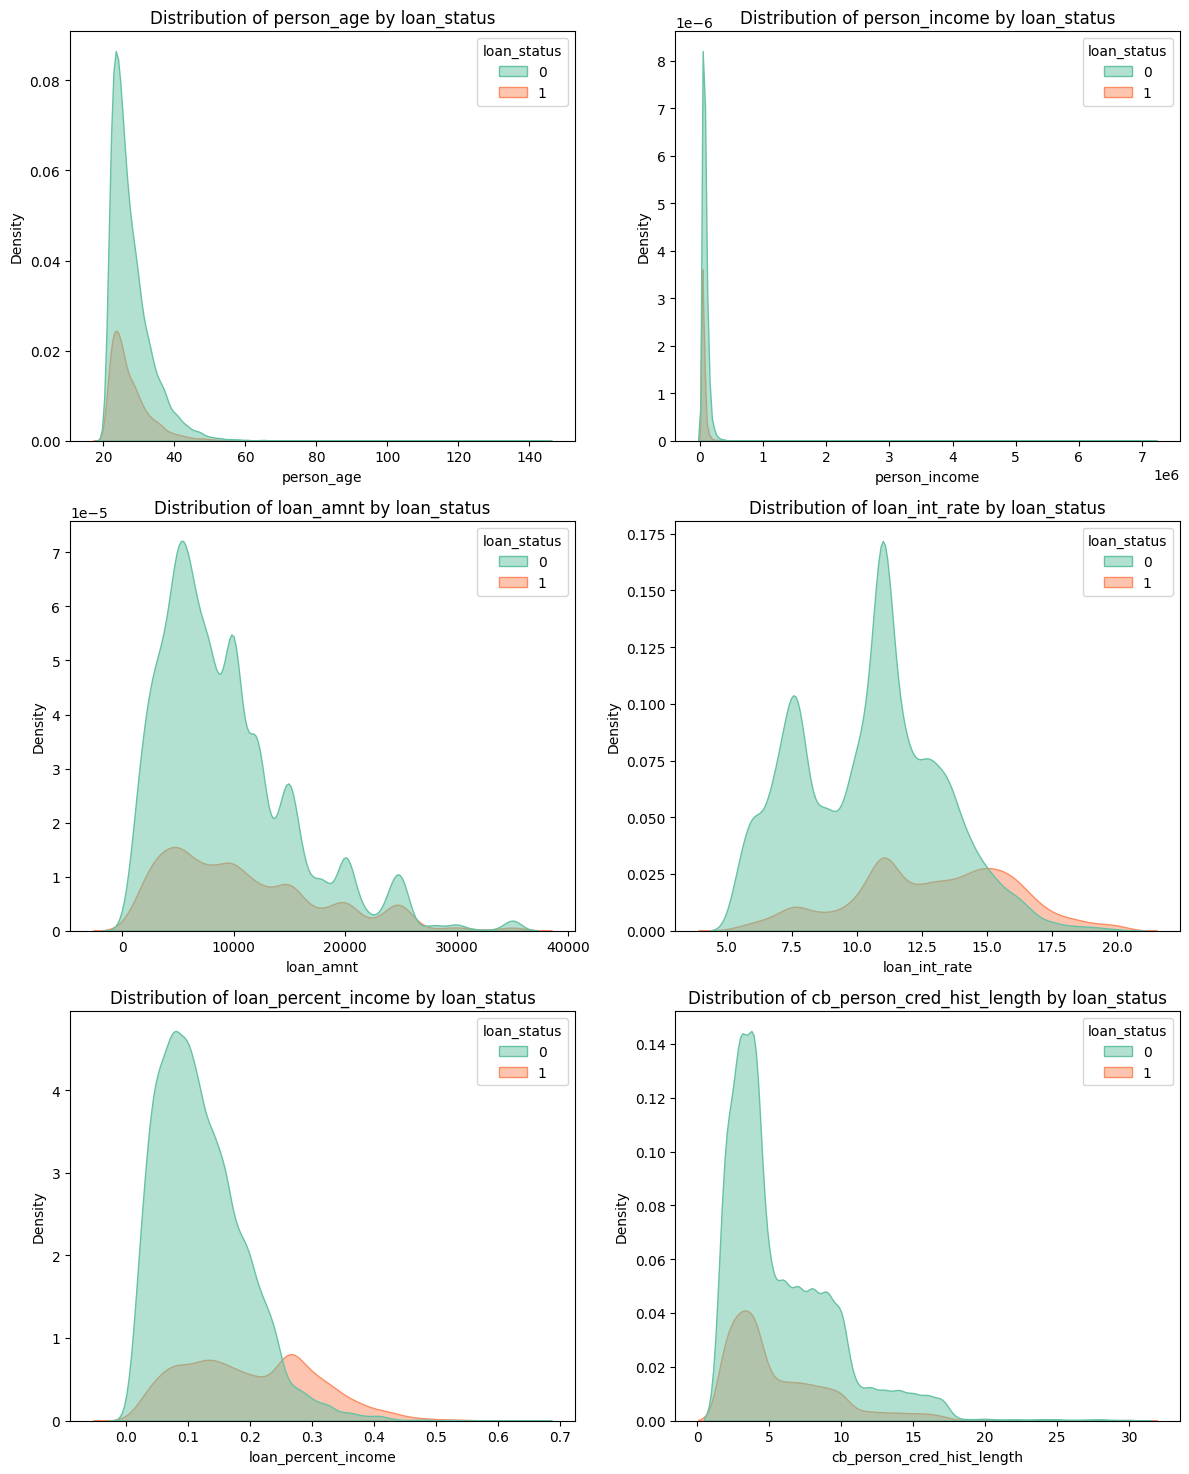

In [ ]:
# Fitur kontinu
continuous_features = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

plot_continuous_distribution(train_df, continuous_features, target_variable)

In [ ]:
def plot_discrete_distribution(dataframe, features, target):

  fig, axes = plt.subplots(
    nrows = math.ceil(len(features)/2),
    ncols = 1 if len(features) == 1 else 2,
    figsize = (6 * (2 if len(features) >= 2 else len(features)), 5 * math.ceil(len(features)/2))
  )

  if len(features) == 1:
    axes = [axes]
  else:
    axes = axes.flatten()

  for i, feature in enumerate(features):

    # Counplot
    sns.histplot(
      data=dataframe,
      x=feature,
      hue=target,
      discrete=True,
      element="step",
      fill=True,
      stat="probability",
      common_norm=False,
      palette="Set2",
      alpha=0.4,
      linewidth=1,
      ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {feature} by {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Mass')
    sns.despine(ax=axes[i])

  for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

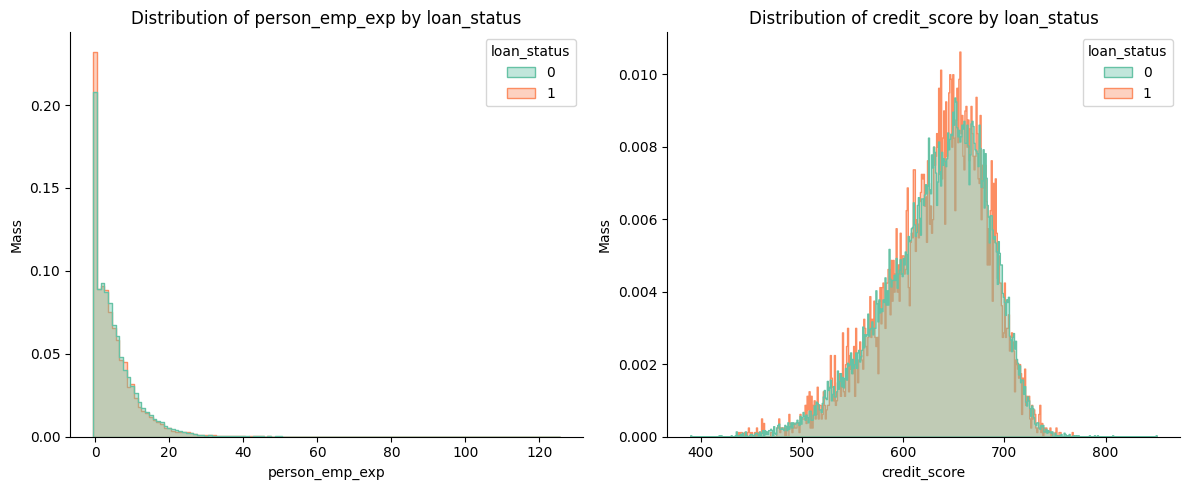

In [ ]:
# Fitur diskrit
discrete_features = ['person_emp_exp', 'credit_score']

plot_discrete_distribution(train_df, discrete_features, target_variable)

In [ ]:
def boxplot(dataframe, features, target):

  fig, axes = plt.subplots(
    nrows = math.ceil(len(features)/2),
    ncols = 1 if len(features) == 1 else 2,
    figsize = (6 * (2 if len(features) >= 2 else len(features)), 5 * math.ceil(len(features)/2))
  )

  if len(features) == 1:
    axes = [axes]
  else:
    axes = axes.flatten()

  for i, feature in enumerate(features):

    # Counplot
    sns.boxplot(
      data=dataframe,
      x=feature,
      hue=target,
      fill=True,
      palette="Set2",
      ax=axes[i]
    )
    axes[i].set_title(f'Boxplot of {feature} by {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Mass')
    sns.despine(ax=axes[i])

  for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

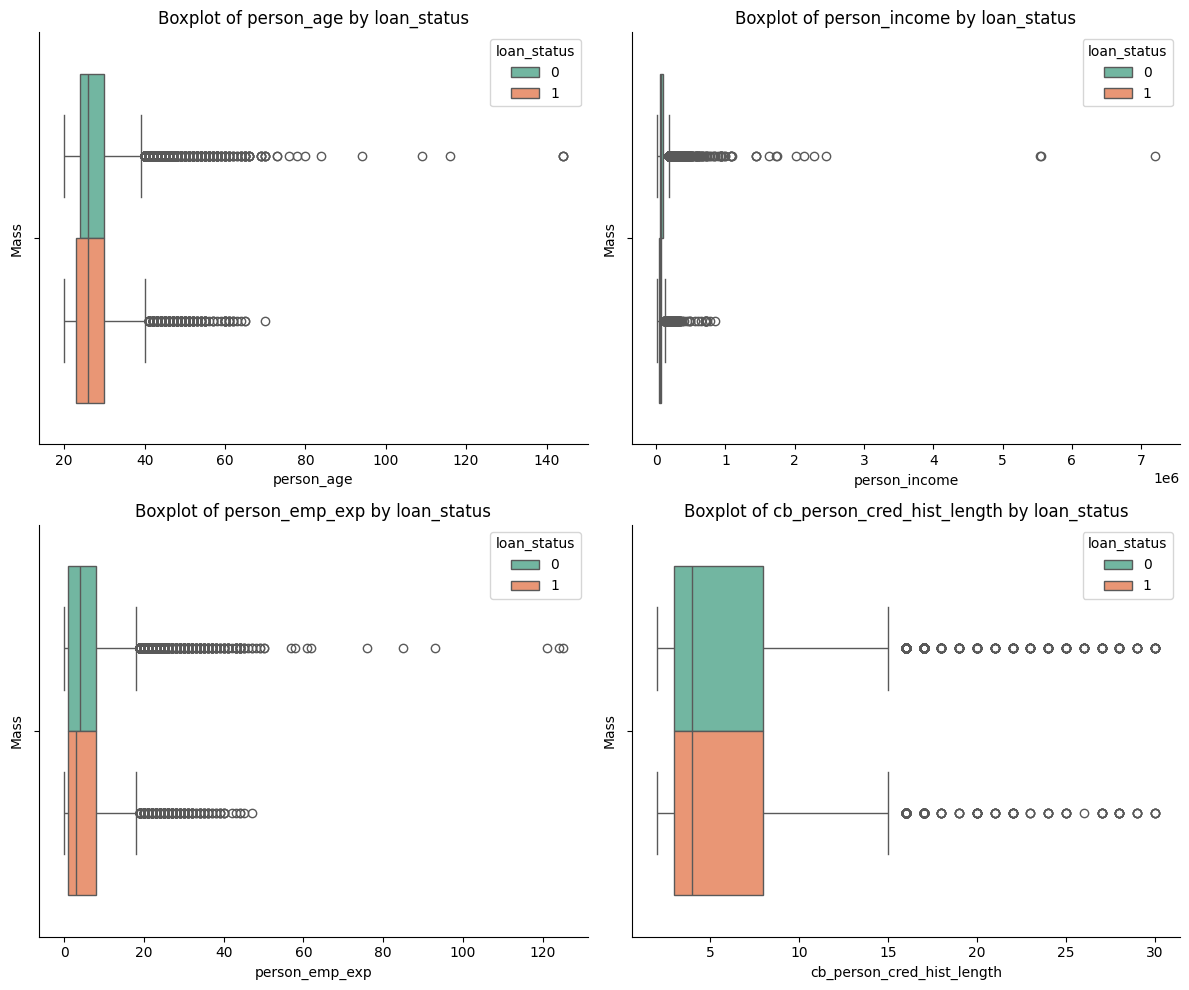

In [ ]:
# Fitur ber-outlier
outlier_features = ['person_age','person_income', 'person_emp_exp', 'cb_person_cred_hist_length']

boxplot(train_df, outlier_features, target_variable)

**Analisis:**

Berdasarkan visualisasi yang disajikan, kita bagi menjadi dua kategori fitur numerik, yaitu kontinu dan diskret.
1. Fitur numerik kontinu terdiri dari `person_age`, `person_income`,`loan_amnt`, `loan_int_rate`, `loan_percent_income`, dan `cb_person_cred_hist_length`. Distribusinya bersifat menceng kanan *(right-skewed)*  terutama pada fitur `person_age` dan `person_income`. Sebagian besar data berpusat pada nilai yang rendah, sedangkan ekornya memanjang tajam ke nilai yang lebih tinggi. Selanjutnya kita analisis pada pola kondisional $P(X =x|Y=\text{status loan})$. Pada fitur `loan_percent_income`, distribusi kelas $1$ memiliki densitas yang lebih tinggi pada rasio utang terhadap pendapatan yang besar, yaitu di atas $20\%$ dibandingkan dengan kelas $0$. Akibatnya, nasabah dengan rasio pinjaman terhadap pendapatan yang tinggi cenderung berada pada kelas $1$ atau *loan* diterima. Lalu, pada fitur `loan_int_rate` dan `loan_amnt`, grafik menunjukkan adanya pola multimodal, yaitu memiliki beberapa puncak. Seperti halnya dengan fitur `loan_percent_income`, bunga pinjaman `loan_int_rate` untuk kelas $1$ memiliki sebaran yang lebih tebal di daerah bunga yang tinggi, yakni di atas $14\%$ jika dibandingkan dengan kelas $0$. Hal ini membuktikan korelasi yang kuat antara `loan_int_rate` dengan status pinjaman karena semakin tinggi bunga pinjaman yang diajukan, maka kreditur akan lebih mendapatkan keuntungan dari pendapatan bunga yang akan diperoleh di masa depan.

2. Fitur numerik diskret terdiri dari `person_emp_exp` dan `credit_score`. Fitur `credit_score` menunjukkan distribusi yang mendekati distribusi normal. Akan tetapi, terdapat *overlap* antara kelas $0$ dan $1$ yang sangat besar, sehingga sulit untuk membedakan status pinjaman hanya berdasarkan skor kredit. Adapun untuk fitur `person_emp_exp` berdistribusi menceng kanan dengan sebagian besar data berada pada nilai yang kecil. Lebih lanjut, sebagian besar data bernilai rendah ini berada pada kelas $0$. Hal ini menunjukkan bahwa kreditur tentunya tidak ingin memberikan pinjaman pada nasabah yang tidak mempunyai penghasilan atau nasabah yang masih sedikit pengalaman bekerja yang menunjukkan belum matang kemampuan finansialnya.

Dari visualisasi di atas, kita menduga bahwa terdapat beberapa fitur yang memiliki data pencilan atau *outliers*. Fitur tersebut di antaranya `person_age`,`person_income`, `person_emp_exp`, dan `cb_person_cred_hist_length`. Keempat fitur ini berdistribusi menceng kanan yang menjadi alasan kuat adanya data pencilan di dalam fitur-fitur tersebut.
1. Pada fitur `person_age`, terdapat pencilan ekstrem dengan usia nasabah mencapai sekitar $144$ tahun. Secara biologis, hal ini tidak masuk akal dan menjadi indikasi untuk membuang data pencilan tersebut.
2. Pada fitur `person_emp_exp`, terdapat data pengalaman kerja mencapai $123$ tahun. Hal ini tidak masuk akal, karena seseorang pasti akan pensiun pada usia $60$-an setelah bekerja $40$ tahunan (asumsikan mulai bekerja saat masuk usia produktif). Kemungkinan besar data pencilan ini merupakan data yang sama dengan pencilan pada fitur usia.
3. Pada `person_income`, terdapat nasabah dengan pendapatan besar di atas rata-rata. Hal ini tentunya masih masuk akal. Nilai pencilan ini hanya perlu dilakukan transformasi sehingga range dari fitur `person_income` tidak terlalu menyebar dan menyebabkan *boxplot* menjadi sangat tipis.

Dari analisis tersebut, kita tahu bahwa semua pencilan berada pada nilai yang besar atau di sisi kanan karena distribusi menceng kanan. Tidak ada nilai pencilan yang berada pada nilai yang rendah. Selanjutnya, data pencilan ini perlu kita atasi sebelum kita melakukan *training* model yang akan dibahas pada bagian **2.2 Handling Outliers**.






### 1.3 Visualisasi 2 — Distribusi Kategorikal

**Pertanyaan:**

Apa distribusi dari fitur-fitur kategorikal kita jika diberikan labelnya? Dan sebaliknya. Yakni, kita mencari

$$ P(X = x \mid Y = \text{Loan Status}) \quad \text{dan} \quad P(Y = \text{Loan Status} \mid X = x). $$

In [ ]:
def plot_categorical_dependence(dataframe, features, target):

  fig, axes = plt.subplots(
    nrows = math.ceil(len(features)/2),
    ncols = 1 if len(features) == 1 else 2,
    figsize = (6 * (2 if len(features) >= 2 else len(features)), 5 * math.ceil(len(features)/2))
  )

  if len(features) == 1:
    axes = [axes]
  else:
    axes = axes.flatten()

  for i, feature in enumerate(features):

    # Stacked bar chart
    crosstab = pd.crosstab(dataframe[feature], dataframe[target], normalize='index')
    crosstab.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[i], alpha=0.8)

    axes[i].set_title(f'Distribution of {target} by {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('mass')

    # Move the legend outside the plot area
    axes[i].legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Rotate x-labels for better readability
    axes[i].tick_params(axis='x', rotation=45)

  for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

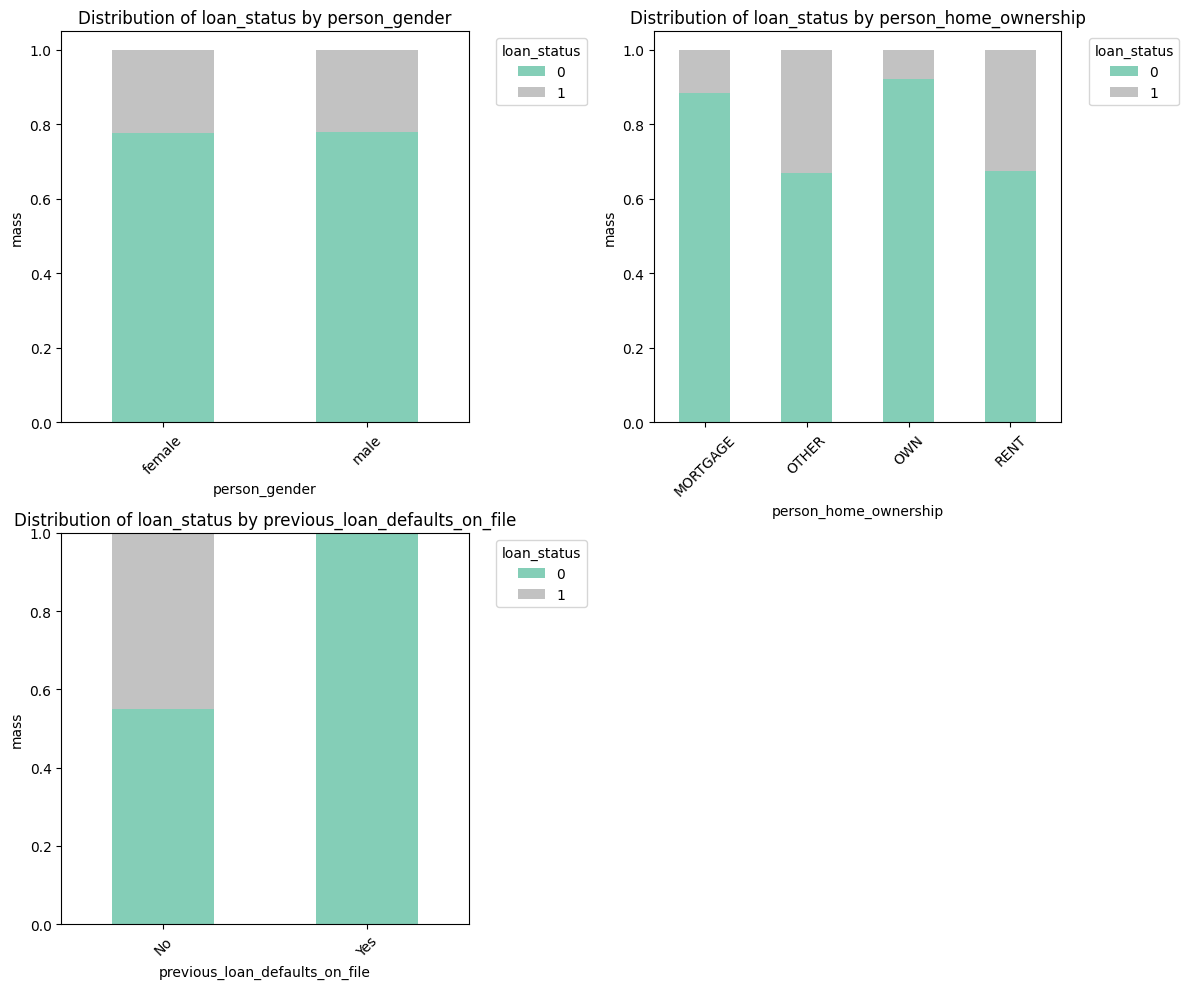

In [ ]:
# Fitur kategorikal
categorical_features =  ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']

plot_categorical_dependence(train_df, categorical_features, target_variable)

In [ ]:
def plot_categorical_distribution(dataframe, features, target):

  fig, axes = plt.subplots(
    nrows = math.ceil(len(features)/2),
    ncols = 1 if len(features) == 1 else 2,
    figsize = (6 * (2 if len(features) >= 2 else len(features)), 5 * math.ceil(len(features)/2))
  )

  if len(features) == 1:
    axes = [axes]
  else:
    axes = axes.flatten()

  for i, feature in enumerate(features):

    # Counplot
    sns.histplot(
      data=dataframe,
      x=feature,
      hue=target,
      discrete=True,
      element="step",
      fill=True,
      stat="probability",
      common_norm=False,
      palette="Set2",
      alpha=0.4,
      linewidth=1,
      ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {feature} by {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Mass')
    sns.despine(ax=axes[i])

  for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

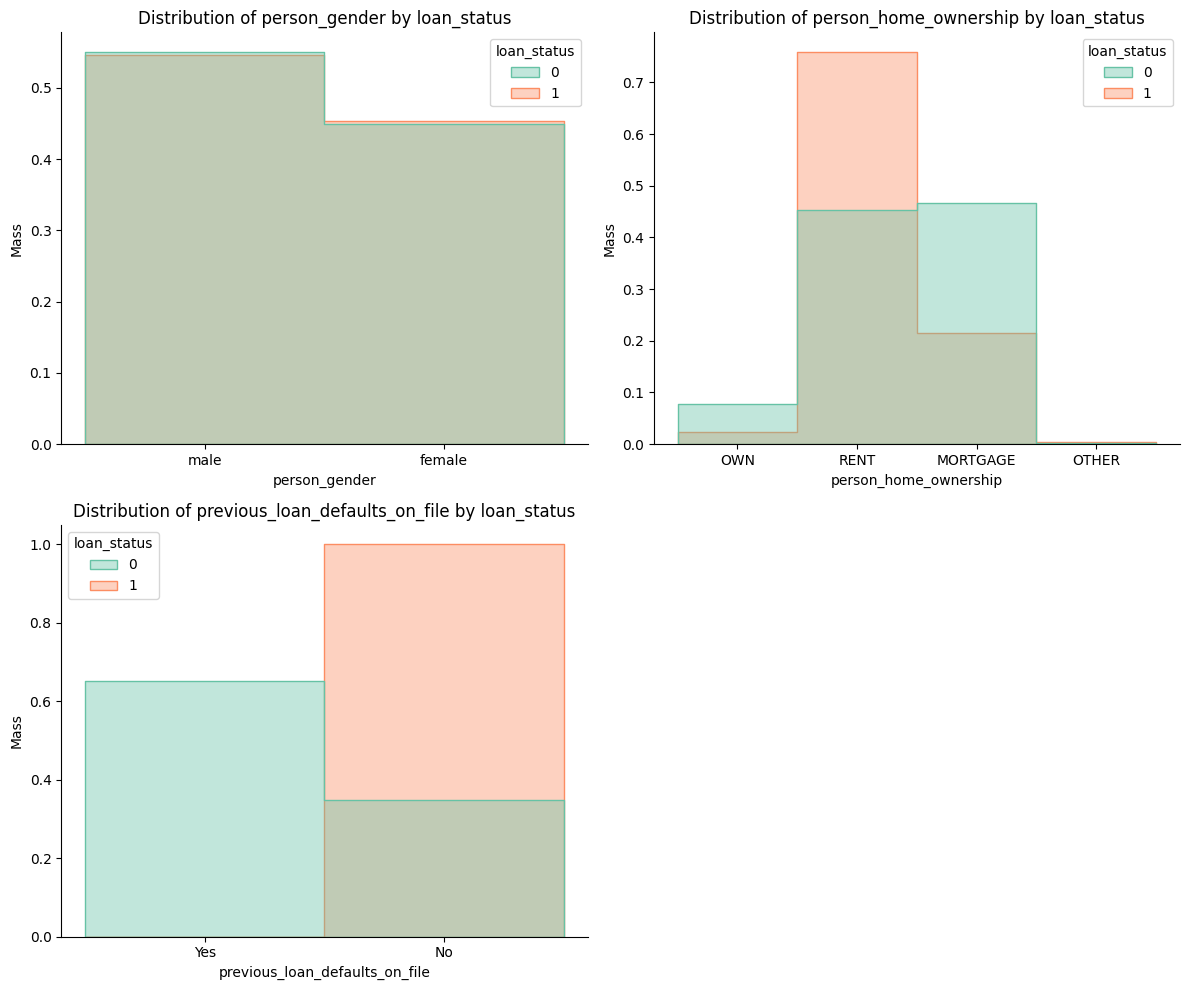

In [ ]:
plot_categorical_distribution(train_df, categorical_features, target_variable)

In [ ]:
from scipy.stats import entropy

def calculate_categorical_stats(dataframe):

  cat_df = dataframe.select_dtypes(include=['object', 'string', 'category'])

  stats_list = []

  for col in cat_df.columns:
    series = cat_df[col].dropna()

    value_counts = series.value_counts(normalize=True)

    cardinality = len(value_counts)
    mode_val = value_counts.index[0]
    mode_prop = value_counts.iloc[0]

    ent = entropy(value_counts, base=2)

    stats_list.append({
      'Feature': col,
      'Cardinality': cardinality,
      'Mode': mode_val,
      'Mode Proportion': mode_prop,
      'Shannon Entropy (H)': ent
    })

  return pd.DataFrame(stats_list).set_index('Feature')

In [ ]:
categorical_stats = calculate_categorical_stats(train_df)
display(categorical_stats)

,Cardinality,Mode,Mode Proportion,Shannon Entropy (H)
Feature,,,,
person_gender,2,male,0.549611,0.992887
person_home_ownership,4,RENT,0.520278,1.298884
previous_loan_defaults_on_file,2,Yes,0.507306,0.999846


**Analisis:**



Pada dataset ini terdapat tiga fitur kategorikal, yaitu `person_gender`, `person_home_ownership`, dan `previous_loan_defaults_on_file`. Berdasarkan visualisasi yang disajikan, kita memvisualisasikan kategori $P(Y=\text{status loan} \mid X=x)$ dan $P(X=x \mid Y= \text{status loan})$.
1. Pada fitur `person_gender`, nasabah laki-laki dan perempuan memiliki proporsi status *loan* yang sama. Hal ini menunjukkan bahwa tidak ada perbedaan distribusi yang signifikan pada sebaran gender dalam kelas $0$ dan $1$. Dengan kata lain, fitur gender bersifat independen terhadap status *loan* dan tidak memiliki kekuatan yang signifikan untuk prediksi status *loan*.
2. Pada fitur `person_home_ownership`, terdapat pengaruh yang cukup signifikan antara status kepemilikan rumah dengan status *loan*. Nasabah dengan status `RENT` dan `OTHER` berada pada kelas $1$ sekitar $33\%$ lebih tinggi dibandingkan nasabah dengan status `MORTGAGE` dan `OWN`. Hal ini menunjukkan bahwa nasabah yang menyewa rumah memiliki kecenderungan profil karakteristik yang berbeda dibadingkan pemilik rumah.
3. Pada fitur `previous_loan_defaults_on_file` menunjukkan pemisahan kelas yang paling kuat. Dapat dilihat bahwa distribusi kelas $1$ seluruhnya berasal dari nasabah yang tidak memiliki riwayat gagal bayar `NO`. Sebaliknya, distribusi kelas $0$ seluruhnya berasal dari nasabah yang memiliki riwayat gagal bayar `YES`. Hal ini menunjukkan korelasi yang kuat antara riwayat gagal bayar dengan status *loan*. Tentunya, kreditur tidak ingin memberikan pinjaman kepada nasabah yang pernah gagal untuk membayar pada pinjaman-pinjaman sebelumnya.
Berdasarkan visualisasi di atas, kita dapat menyimpulkan bahwa fitur `person_home_ownership` dan `previous_loan_defaults_on_file` adalah fitur yang memuat informasi berharga untuk prediksi status *loan*, sedangkan fitur `person_gender` dapat dikatakan sebagai fitur *noise* yang tidak membedakan status *loan* secara signifikan.








### 1.4 Visualisasi 3 — Korelasi Antar Fitur

**Pertanyaan:**

Bagaimana hubungan atau interaksi antar fitur? Secara khusus, kita mencari

- *Pearson* untuk pasangan numerikal-numerikal,  
- *Cramér's V* untuk pasangan kategorikal-kategorikal,
- *Correlation Ratio* untuk pasangan kategorikal-numerikal.

In [ ]:
!pip install dython

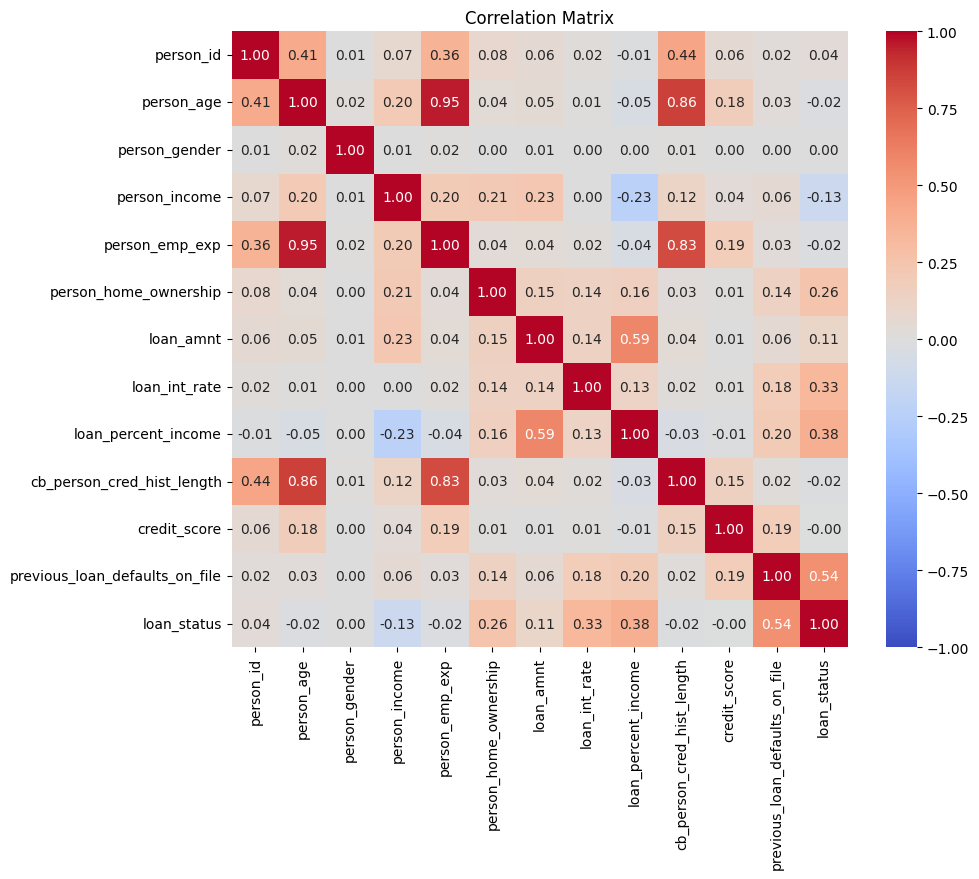

In [ ]:
from dython.nominal import associations

df_dython = train_df.copy()

for col in df_dython.select_dtypes(include=['string', 'object', 'category']).columns:
    df_dython[col] = df_dython[col].astype('object')

dython_result = associations(
  df_dython,
  figsize=(10, 8),
  title="Correlation Matrix",
  cmap='coolwarm',
)

plt.show()

**Analisis:**

Berdasarkan matriks korelasi yang disajikan, kita dapat mengevaluasi kekuatan interaksi antar fitur dalam dataset. Nilai pada matriks korelasi berada pada interval $[-1,1]$. Nilai yang mendekati $1$ atau $-1$ menunjukkan korelasi yang kuat, sementara nilai yang mendekati $0$ menunjukkan tidak adanya hubungan linear. Kita bagi analisis ini menjadi dua poin utama:

1. Korelasi terhadap `loan_status` atau target variabel.
    - Fitur `previous_loan_defaults_on_file` memiliki korelasi positif terkuat terhadap target dengan nilai $0.54$. Angka ini memvalidasi hasil eksplorasi data analisis kita sebelumnya, bahwa rekam jejak gagal bayar adalah indikator paling penting dalam menentukan status *loan*.
    - Fitur `loan_percent_income`, `loan_int_rate`, dan `person_home_ownership` secara berturut-turut memiliki nilai korelasi $0.38, 0.33,$ dan $0.26$. Hal ini menunjukkan korelasi positif yang moderat hingga cukup kuat. Hal ini tampaknya masuk akal karena semakin tinggi rasio utang terhadap pendapatan dan suku bunga yang diberikan, maka risiko status *loan* diterima akan semakin tinggi. Begitu pula dengan status kepemilikan rumah yang sudah dibahas sebelumnya.
    - Fitur `person_income` memiliki korelasi negatif yang lemah yaitu $-0.13$. Hal ini menunjukkan bahwa nasabah dengan pendapatan lebih tinggi memiliki sedikit kecenderungan untuk berada status *loan* ditolak.
    - Fitur `person_gender`, `credit_score`, dan `person_id` secara berturut-turut memiliki nilai korelasi $0.00, 0.00,$ dan $0.04$ yang mendekati nol. Hal ini menunjukkan bahwa ketiga fitur tersebut bertindak sebagai *noise* dan tidak memengaruhi hasil prediksi status *loan*.


2. Korelasi antar fitur independen. Analisis korelasi antar fitur prediktor penting dilakukan untuk menghindari *redundant* yang dapat mengganggu stabilitas model, terutama pada model regresi linier atau logistik.
    - Terdapat korelasi positif yang sangat ekstrem antara `person_age` dan `person_emp_exp` dengan nilai $0.95$. Hal ini berarti semakin tua seseorang, maka semakin lama pula pengalaman kerjanya.
    -  Lalu, terdapat hubungan antara `person_age` dengan `cb_person_cred_hist_length` dengan nilai korelasi $0.86$, serta `person_emp_exp` dengan `cb_person_cred_hist_length` dengan nilai korelasi $0.83$. Hal ini menunjukkan bahwa usia yang lebih tua berkorelasi langsung dengan riwayat kredit yang lebih panjang.
    - Terakhir, terdapat korelasi moderat antara `loan_amnt` dengan `loan_percent_income` dengan nilai $0.59$. Hal ini akibat dari fitur `loan_percent_income` yang merupakan $\displaystyle{\text{loan_percent_income} = \frac{\text{loan_amnt}}{\text{person_income}}}$.


---
## 2. Data Cleaning and Preprocessing

> **Tujuan:** Menyiapkan data untuk training model.
> **Requirement:** Sertakan **penjelasan** untuk setiap langkah.

> ⚠️ **Ingat:** Fit transformer **hanya pada training data**, lalu transform train dan test secara terpisah untuk menghindari data leakage.

In [ ]:
TARGET_COL = 'loan_status'
ID_COL     = 'person_id'

CAT_COLS = ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']
NUM_COLS = [c for c in train_df.columns if c not in CAT_COLS + [TARGET_COL, ID_COL]]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

# Buat salinan
train = train_df.copy()
test  = test_df.copy()

Categorical: ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']
Numerical:   ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


### 2.1 Handling Missing Values

**Penjelasan:**

Tidak ada data yang memiliki *missing value*, sehingga tidak diperlakukan imputasi.

In [ ]:
# Tidak perlu dilakukan imputasi

### 2.2 Handling Outliers

**Penjelasan:**

Terdapat beberapa data *outliers* pada fitur-fitur `person_age`,`person_income`, `person_emp_exp`, dan `cb_person_cred_hist_length`. Jika tidak dilakukan penanganan pada fitur ini, tentunya akan berpengaruh terhadap hasil akhir model. Salah satu metode yang dapat digunakan untuk menangani data pencilan ini adalah dengan metode winsorisasi yang mengurangi dampak *outliers* dengan mengganti nilai pencilan dengan nilai persentil tertentu dan bukan dengan menghapus pencilan. Winsorisasi bekerja dengan membatasi atau mengganti nilai di luar ambang persentil tertentu. Dalam kasus ini, ambang persentil dibuat bervariasi. Sebagai contoh, untuk fitur `person_age` dilakukan winsorisasi $0.025\%$ yang artinya titik data terendah diganti dengan nilai pada persentil ke-$0.025$, dan $0.025%$ titik data tertinggi diganti dengan nilai pada persentil ke-$99.975$. Untuk fitur `person_income`, `person_emp_exp`, dan `cb_person_cred_hist_length` secara berturut-turut dilakukan winsorisasi $0.1\%, 0.05\%,$ dan $0.1\%$. Pemilihan penggunaan metode winsorisasi dibandingkan metode lainnya dalam mengatasi data pencilan adalah karena data pencilan pada metode winsorisasi tidak dibuang. Hal ini masuk akal karena mungkin saja data pencilan ini berpengaruh apabila nilainya menjadi lebih kecil dengan persentil tertentu, sehingga tidak membuang informasi awal yang dimiliki data.

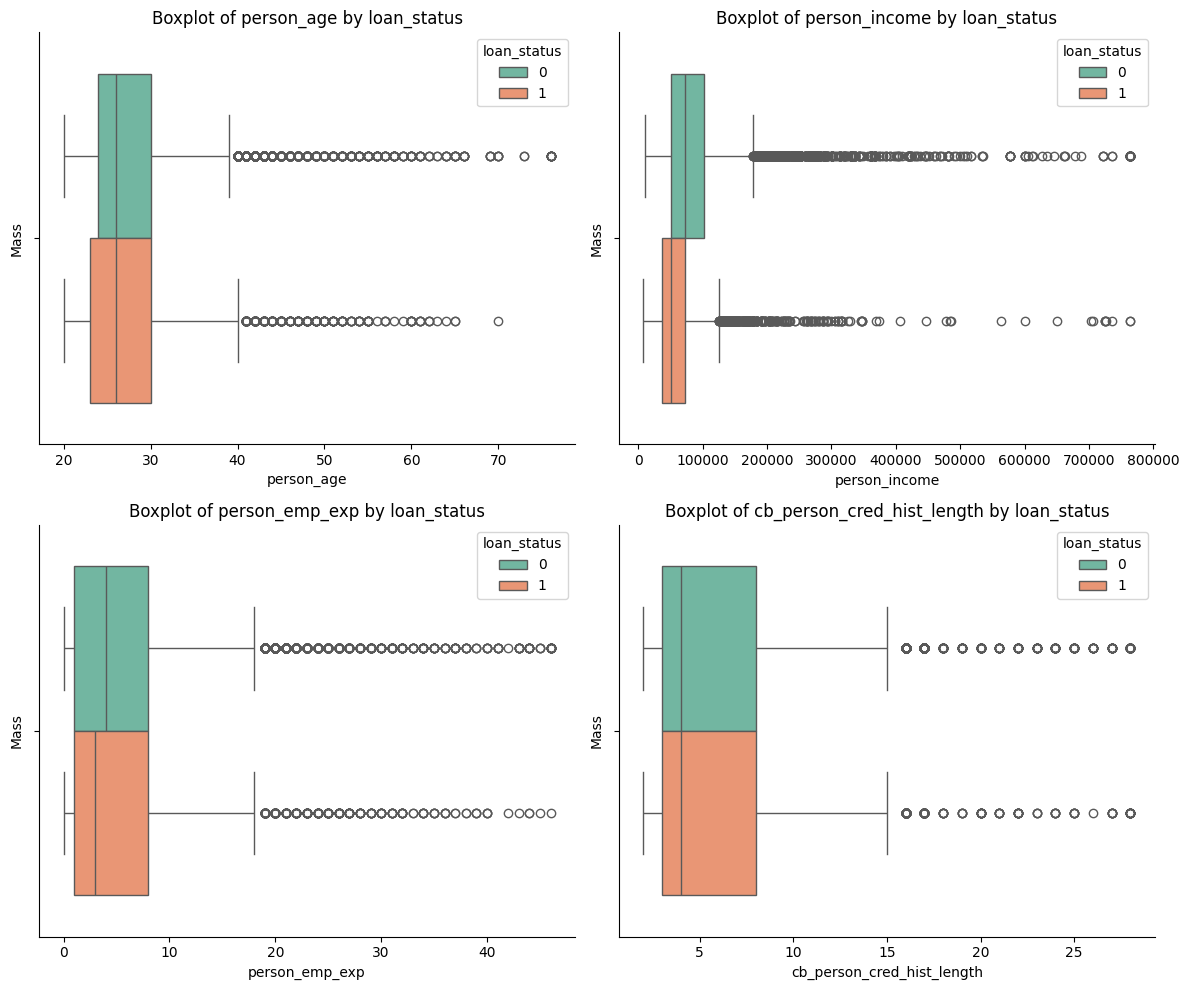

In [ ]:
import numpy as np

def get_winsorize_thresholds(df_train, features, alphas):
  thresholds = {}
  for i, col in enumerate(features):
    upper_bound = df_train[col].quantile(1 - alphas[i])
    thresholds[col] = upper_bound
  return thresholds

def apply_winsorize_thresholds(df, thresholds):
    df_clean = df.copy()
    for col, upper_bound in thresholds.items():
        df_clean[col] = np.clip(df_clean[col], a_min=None, a_max=upper_bound)
    return df_clean

alphas = [0.00025, 0.001, 0.0005, 0.001]

winsorize_thresholds = get_winsorize_thresholds(train, outlier_features, alphas)

train = apply_winsorize_thresholds(train, winsorize_thresholds)
test = apply_winsorize_thresholds(test, winsorize_thresholds)

boxplot(train, outlier_features, target_variable)

### 2.3 Encoding Fitur Kategorik

**Penjelasan:**

Pada dataset yang diberikan, terdapat tiga fitur kategorikal, yaitu `person_gender`, `person_home_ownership`, dan `previous_loan_defaults_on_file`. Algoritma *machine learning* membutuhkan data dalam format numerik, sehingga perlu dilakukan *encoding*.
- Fitur `person_gender` termasuk data nominal yang tidak mengenal urutan. Akan tetapi, karena data ini bersifat biner, kita cukup melakukan *ordinary encoding* dengan mengubahnya menjadi angka $0$ dan $1$.
- Fitur `person_home_ownership` termasuk data nominal yang tidak mengenal urutan. Penggunaan *ordinal encoding* dengan mengubah kategori menjadi angka $0, 1, 2,$ dan $3$ dapat dilakukan. Hal ini karena status kepemilikan rumah tidak terlalu berpengaruh signifikan terhadap status *loan*.
- Fitur `previous_loan_defaults_on_file` termasuk data nominal yang tidak mengenal urutan. Karena fitur ini bersifat biner, maka cukup dilakukan encoding sederhana saja dengan mengubah menjadi angka $0$ dan $1$.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

ord_encoder = OrdinalEncoder()

train[CAT_COLS] = ord_encoder.fit_transform(train[CAT_COLS])
test[CAT_COLS] = ord_encoder.transform(test[CAT_COLS])

### 2.4 Feature Scaling

**Penjelasan:**

*Feature scaling* perlu dilakukan jika kita ingin menerapkan algoritma *machine learning* berbasis perhitungan jarak atau algoritma yang menggunakan optimisasi *gradient descent*. *Scaling* dilakukan khususnya pada fitur-fitur yang berdistribusi menceng kanan. Model akan menjadi bias jika tidak dilakukan *scaling* karena fitur dengan rentang nilai yang besar akan mendominasi fitur dengan rentang nilai yang kecil. Berdasarkan hasil analisis distribusi fitur sebelumnya, kita menerapkan dua tahap transformasi secara berurutan:
1. Dilakukan transformasi logaritmik dengan `np.log1p` untuk beberapa fitur numerik (`person_age`, `person_income`, `loan_percent_income`, dan `cb_person_cred_hist_length`) teridentifikasi memiliki distribusi yang sangat menceng kanan (*right-skewed*). Kita mengaplikasikan transformasi logaritmik dengan persamaan $y=\ln(1+x)$. Transformasi ini berfungsi untuk memadatkan nilai-nilai ekstrem di ekor kanan, sehingga sebaran data tertarik ke tengah dan distribusinya mendekati distribusi normal. Pennambahan konstanta 1 sebelum dilogaritmakan untuk mencegah nilai tak terdefinisi jika terdapat data yang bernilai $0$, yakni $\ln(0) = \text{undefined}$.
2. Selanjutnya dilakukan standardisasi `StandardScaler` untuk fitur-fitur numerik. Metode ini mengubah skala data sehingga setiap fitur memiliki nilai rata-rata nol dan variansi satu menggunakan persamaan $\displaystyle{z=\frac{x-\mu}{\sigma}}$. Proses ini memastikan seluruh fitur berada pada *range* nilai yang sama.

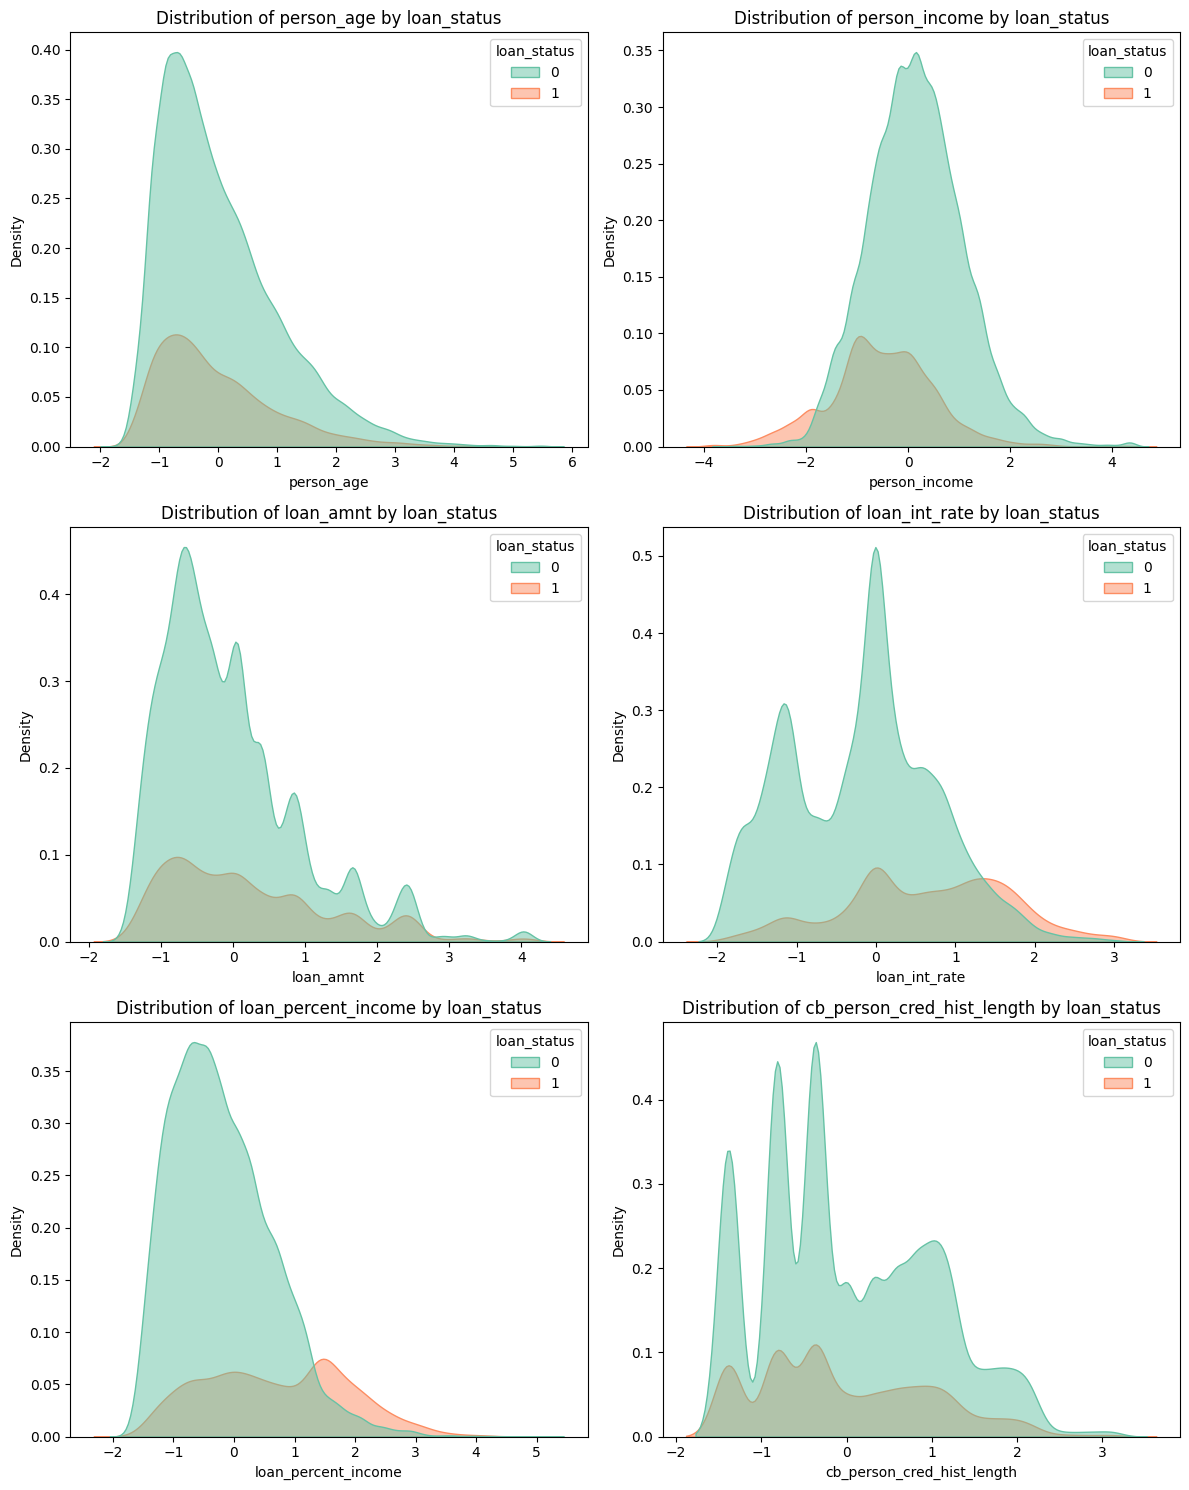

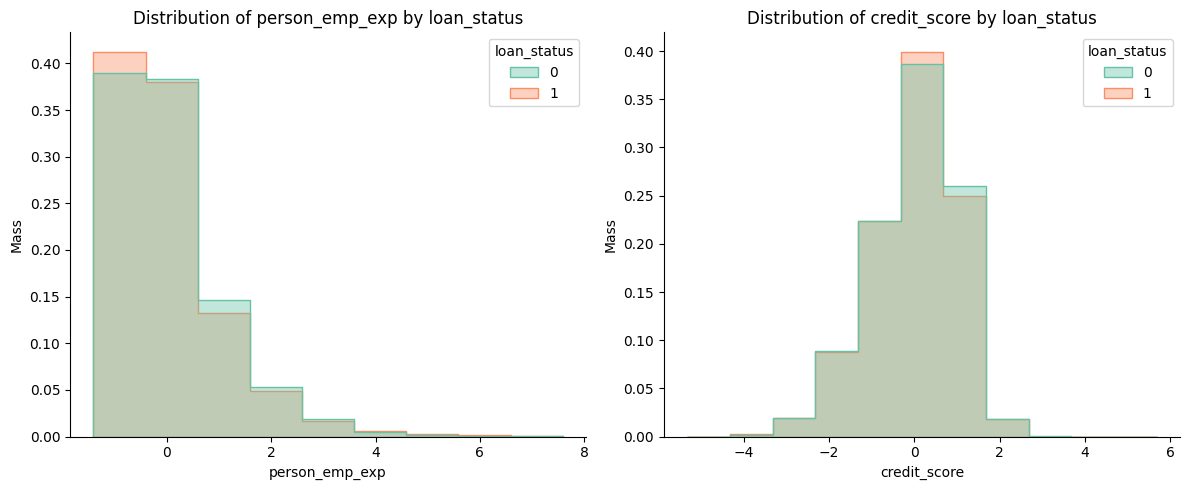

In [ ]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer

SKEW_COLS = ['person_age', 'person_income', 'loan_percent_income', 'cb_person_cred_hist_length']
log_scaler = FunctionTransformer(np.log1p, validate=False)
train[SKEW_COLS] = log_scaler.fit_transform(train[SKEW_COLS])
test[SKEW_COLS]  = log_scaler.transform(test[SKEW_COLS])

scaler = StandardScaler()
train[NUM_COLS] = scaler.fit_transform(train[NUM_COLS])
test[NUM_COLS]  = scaler.transform(test[NUM_COLS])

plot_continuous_distribution(train, continuous_features, target_variable)
plot_discrete_distribution(train, discrete_features, target_variable)

### 2.5 (Opsional) Feature Engineering / Selection

In [ ]:
# train = train.drop('person_age', axis=1)
# test = test.drop('person_age', axis=1)

train.head(20)

,person_id,person_age,person_gender,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,6049,-0.665627,1.0,-0.249556,-0.572249,2.0,-0.823150,-1.687749,-0.815588,-0.366389,0.464300,1.0,0
1,3347,-0.888546,0.0,-0.698902,-0.572249,3.0,0.224243,-0.001061,1.180019,-1.385501,0.026852,1.0,0
2,17999,0.329988,0.0,2.280035,0.270802,0.0,0.065547,0.563408,-1.200464,1.016459,0.106388,1.0,0
3,24989,0.509045,0.0,0.633249,0.776632,0.0,-0.569236,0.832203,-0.942668,0.806262,0.981285,0.0,0
4,23232,0.329988,1.0,0.136270,0.270802,0.0,-0.251845,-0.169058,-0.318876,0.806262,0.225692,1.0,0
5,27929,0.850454,0.0,0.523016,0.776632,3.0,0.065547,-1.250958,-0.318876,0.571281,-1.424682,1.0,0
6,23614,-0.046766,0.0,-0.626881,-0.403639,3.0,-0.093149,-0.313535,0.622991,0.806262,0.921633,1.0,0
7,20372,1.171768,1.0,-0.924137,0.439412,3.0,-0.807280,-0.001061,-0.318876,1.016459,-0.589553,1.0,0
8,35402,-0.245361,1.0,1.131606,-0.572249,0.0,-0.741104,0.099737,-1.200464,-0.366389,-0.470249,1.0,0
9,31459,2.035792,1.0,-0.935936,1.956903,3.0,0.664624,0.660846,2.229683,1.825374,-1.444566,0.0,1


### 2.6 Train-Validation Split

In [ ]:
feature_cols = [c for c in train.columns if c not in [TARGET_COL, ID_COL]]

X            = train[feature_cols]
y            = train[TARGET_COL]
X_test_final = test[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(
  X, y,
  test_size=0.2,
  random_state=RANDOM_STATE,
  stratify=y
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (28800, 11) | y_train: (28800,)
X_val:   (7200, 11) | y_val:   (7200,)


---
## 3. Modeling and Validation

> **Metrik utama:** Macro F1-Score

In [ ]:
# Helper: evaluasi model dan simpan hasil
results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
  y_pred = model.predict(X_val)
  print(f"{'='*55}")
  print(f"  {model_name}")
  print(f"{'='*55}")
  print(classification_report(y_val, y_pred,
                              target_names=['Rejected (0)', 'Approved (1)']))
  macro_f1 = f1_score(y_val, y_pred, average='macro')
  print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
  return macro_f1

### 3.1 Bagging — Random Forest

**Konsep:** Melatih banyak Decision Tree secara independen pada subset data dan fitur yang berbeda (bootstrap sampling). Prediksi akhir = voting mayoritas.

In [ ]:
!pip install --upgrade scikit-learn

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

base_models = {
  "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
  "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
  "Naive-Bayes": GaussianNB()
}

for name, model in base_models.items():

  bagging_clf = BaggingClassifier(
    estimator=model,
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=None
  )

  model.fit(X_train, y_train)
  results[name] = evaluate_model(model, X_val, y_val, name)

  bagging_clf.fit(X_train, y_train)
  results['Bagged ' + name] = evaluate_model(bagging_clf, X_val, y_val, 'Bagged ' + name)

  print()

  Decision Tree
              precision    recall  f1-score   support

Rejected (0)       0.93      0.93      0.93      5600
Approved (1)       0.75      0.75      0.75      1600

    accuracy                           0.89      7200
   macro avg       0.84      0.84      0.84      7200
weighted avg       0.89      0.89      0.89      7200

>>> Macro F1-Score: 0.8397

  Bagged Decision Tree
              precision    recall  f1-score   support

Rejected (0)       0.93      0.96      0.95      5600
Approved (1)       0.85      0.77      0.81      1600

    accuracy                           0.92      7200
   macro avg       0.89      0.86      0.88      7200
weighted avg       0.92      0.92      0.92      7200

>>> Macro F1-Score: 0.8771


  Logistic Regression
              precision    recall  f1-score   support

Rejected (0)       0.92      0.93      0.93      5600
Approved (1)       0.75      0.73      0.74      1600

    accuracy                           0.89      7200
   macro a

In [ ]:
rf_model = RandomForestClassifier(
  n_estimators=300,
  max_features='sqrt',
  min_samples_split=3,
  random_state=RANDOM_STATE,
  n_jobs=-1
)

rf_model.fit(X_train, y_train)

results['Random Forest'] = evaluate_model(rf_model, X_val, y_val, 'Random Forest')

  Random Forest
              precision    recall  f1-score   support

Rejected (0)       0.93      0.97      0.95      5600
Approved (1)       0.86      0.75      0.80      1600

    accuracy                           0.92      7200
   macro avg       0.90      0.86      0.87      7200
weighted avg       0.91      0.92      0.91      7200

>>> Macro F1-Score: 0.8737



In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=500,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et_model.fit(X_train, y_train)

results['Extra Trees'] = evaluate_model(et_model, X_val, y_val, 'Extra Trees')

  Extra Trees
              precision    recall  f1-score   support

Rejected (0)       0.93      0.96      0.95      5600
Approved (1)       0.84      0.75      0.79      1600

    accuracy                           0.91      7200
   macro avg       0.89      0.86      0.87      7200
weighted avg       0.91      0.91      0.91      7200

>>> Macro F1-Score: 0.8699



**Analisis Kinerja Random Forest:**  


Model Random Forest menghasilkan *Macro F1-Score* sebesar $0.8737$. Secara umum, model ini sudah memiliki performa yang sangat baik. Adapun untuk tiap kelas prediksi:
- Kelas $0$, yaitu status *loan* ditolak/*rejected*. Pertama, Precision bernilai $0.93$, artinya ketika model memprediksi status *rejected*, $93\%$ hasil prediksi tersebut di antaranya benar. Kedua, Recall bernilai $0.97$, artinya dari seluruh data aktual dengan kelas *rejected*, model berhasil menemukan $97\%$ data *rejected*. Ketiga, F1-Score bernilai $0.95$, artinya keseimbangan precision dan recall sangat baik di kelas ini.
- Kelas $1$, yaitu status *loan* diterima/*approved*. Pertama, Precision bernilai $0.86$, artinya ketika model memprediksi status *approved*, $86\%$ hasil prediksi tersebut di antaranya benar. Kedua, Recall bernilai $0.75$, artinya dari seluruh data aktual dengan kelas *approved*, model berhasil menemukan $75\%$ data *approved*, sehingga $25\%$ nasabah yang layak malah ditolak status pinjamannya. Ketiga, F1-Score bernilai $0.80$, artinya keseimbangan precision dan recall lumayan baik di kelas ini, tetapi lebih rendah dibandingkan kelas $0$.

Adapun kelebihan dan kekurangan Bagging di antaranya sebagai berikut.
- Kelebihan: Memastikan adanya keberagaman pada model. Hal ini dicapai karena setiap *base estimators* dilatih menggunakan subset data yang berbeda-beda yang merupakan hasil dari pengambilan sampel dengan pengembalian (bootstrap sampling).
- Kekurangan: Keberagaman ensemble menjadi berkurang akibat fitur yang dominan digunakan secara berulang-ulang di berbagai pohon keputusan yang berbeda.

### 3.2 Boosting — Gradient Boosting

**Konsep:** Membangun model secara sekuensial; setiap model baru memperbaiki residual error model sebelumnya menggunakan gradient descent pada fungsi loss.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
ada_model = AdaBoostClassifier(
    estimator=ada_dt,
    n_estimators=500,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)

ada_model.fit(X_train, y_train)
results['AdaBoost'] = evaluate_model(ada_model, X_val, y_val, 'AdaBoost')

  AdaBoost
              precision    recall  f1-score   support

Rejected (0)       0.93      0.93      0.93      5600
Approved (1)       0.75      0.75      0.75      1600

    accuracy                           0.89      7200
   macro avg       0.84      0.84      0.84      7200
weighted avg       0.89      0.89      0.89      7200

>>> Macro F1-Score: 0.8396



In [ ]:
!pip install xgboost lightgbm

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gb_model = HistGradientBoostingClassifier(
  learning_rate=0.1,
  max_depth=3,
  random_state=RANDOM_STATE
)

hist_gb_model.fit(X_train, y_train)

results['Histogram Gradient Boosting'] = evaluate_model(hist_gb_model, X_val, y_val, 'Histogram Gradient Boosting')

  Histogram Gradient Boosting
              precision    recall  f1-score   support

Rejected (0)       0.93      0.96      0.94      5600
Approved (1)       0.85      0.73      0.79      1600

    accuracy                           0.91      7200
   macro avg       0.89      0.85      0.87      7200
weighted avg       0.91      0.91      0.91      7200

>>> Macro F1-Score: 0.8667



In [ ]:
from xgboost import XGBClassifier

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
  n_estimators=1104,
  learning_rate=0.1,
  max_depth=3,
  scale_pos_weight=ratio,
  eval_metric='mlogloss',
  subsample = 0.6641,
  colsample_bytree = 0.69,
  random_state=RANDOM_STATE,
)

xgb_model.fit(X_train, y_train)

results['XGBoost'] = evaluate_model(xgb_model, X_val, y_val, 'XGBoost')

  XGBoost
              precision    recall  f1-score   support

Rejected (0)       0.97      0.90      0.93      5600
Approved (1)       0.72      0.89      0.80      1600

    accuracy                           0.90      7200
   macro avg       0.85      0.90      0.87      7200
weighted avg       0.91      0.90      0.90      7200

>>> Macro F1-Score: 0.8657



In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
  boosting_type='gbdt',
  objective='binary',
  learning_rate=0.6,
  n_estimators=1100,
  subsample=0.6641,
  is_unbalance=True,
  random_state=RANDOM_STATE
)

lgb_model.fit(X_train, y_train)

results['LightGBM'] = evaluate_model(lgb_model, X_val, y_val, 'LightGBM')

[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222222 -> initscore=-1.252763
[LightGBM] [Info] Start training from score -1.252763
  LightGBM
              precision    recall  f1-score   support

Rejected (0)       0.94      0.96      0.95      5600
Approved (1)       0.84      0.79      0.81      1600

    accuracy                           0.92      7200
   macro avg       0.89      0.87      0.88      7200
weighted avg       0.92      0.92      0.92      7200

>>> Macro F1-Score: 0.8819



In [ ]:
gb_model = GradientBoostingClassifier(
  n_estimators=1104,
  learning_rate=0.1,
  max_depth=3,
  subsample=0.6641,
  random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)

results['Gradient Boosting'] = evaluate_model(gb_model, X_val, y_val, 'Gradient Boosting')

  Gradient Boosting
              precision    recall  f1-score   support

Rejected (0)       0.94      0.97      0.95      5600
Approved (1)       0.87      0.77      0.82      1600

    accuracy                           0.92      7200
   macro avg       0.90      0.87      0.89      7200
weighted avg       0.92      0.92      0.92      7200

>>> Macro F1-Score: 0.8853



**Analisis Kinerja Gradient Boosting:**  

Model Gradient Boosting menghasilkan *Macro F1-Score* sebesar $0.8853$. Secara umum, model ini sudah memiliki performa yang sangat baik. Model ini lebih baik dibandingkan dengan Random Forest dengan *Macro F1-Score* bernilai $0.8737$.  Adapun untuk tiap kelas prediksi:
- Kelas $0$, yaitu status *loan* ditolak/*rejected*. Pertama, Precision bernilai $0.94$, artinya ketika model memprediksi status *rejected*, $94\%$ hasil prediksi tersebut di antaranya benar. Kedua, Recall bernilai $0.97$, artinya dari seluruh data aktual dengan kelas *rejected*, model berhasil menemukan $97\%$ data *rejected*. Ketiga, F1-Score bernilai $0.95$, artinya keseimbangan precision dan recall sangat baik di kelas ini.
- Kelas $1$, yaitu status *loan* diterima/*approved*. Pertama, Precision bernilai $0.87$, artinya ketika model memprediksi status *approved*, $87\%$ hasil prediksi tersebut di antaranya benar. Kedua, Recall bernilai $0.77$, artinya dari seluruh data aktual dengan kelas *approved*, model berhasil menemukan $77\%$ data *approved*, sehingga $23\%$ nasabah yang layak malah ditolak status pinjamannya. Ketiga, F1-Score bernilai $0.82$, artinya keseimbangan precision dan recall lumayan baik di kelas ini, tetapi lebih rendah dibandingkan kelas $0$.

Adapun kelebihan dan kekurangan Boosting di antaranya sebagai berikut.
- Kelebihan: Mampu meningkatkan performa kumpulan *weak learners*, yakni model sederhana yang performanya hanya sedikit lebih baik dari tebakan acak, menjadi sebuah *strong learner* tunggal. Bekerja secara adaptif untuk memperbaiki kesalahan model sebelumnya, baik dengan memperbesar bobot pada data yang salah diprediksi pada AdaBoost atau dengan memanfaatkan nilai residual/*loss gradient* pada Gradient Boosting.
- Kekurangan: Penentuan learning rate ($\eta$) sangat penting dan sensitif pada pengoptimalan yang berbasis gradien. Jika angkanya terlalu kecil, maka akan membutuhkan langkah iterasi yang terlalu banyak sehingga waktu komputasi menjadi lambat. Sebaliknya, jika $\eta$ terlalu besar, pencarian bisa melampaui batas maksimum.


### 3.3 Stacking (Minimal 3 Base Model Berbeda)

**Konsep:** Base learners (level-0) dilatih dengan cross-validation; prediksi out-of-fold mereka menjadi fitur input untuk meta-learner (level-1) yang memberikan prediksi akhir.

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class ThresholdEnsemble(BaseEstimator, ClassifierMixin):
  def __init__(self, ensemble_model, threshold=0.5):
      self.ensemble_model = ensemble_model
      self.threshold = threshold
      self.classes_ = None

  def fit(self, X, y):
      self.ensemble_model.fit(X, y)
      self.classes_ = self.ensemble_model.classes_
      return self

  def predict(self, X):
    probs = self.ensemble_model.predict_proba(X)[:, 1]
    return (probs >= self.threshold).astype(int)

  def predict_proba(self, X):
    return self.ensemble_model.predict_proba(X)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.base import BaseEstimator, ClassifierMixin

base_estimators = [
  ('Bagged Decision Tree',  base_models['Decision Tree']),
  ('LightGBM',  lgb_model),
  ('Gradient Boosting', gb_model),
]

meta_learner = LogisticRegression()

stacking_prob_model = StackingClassifier(
  estimators=base_estimators,
  final_estimator=meta_learner,
  cv=10,
  passthrough = True,
  n_jobs=-1,
)

stacking_final_model = ThresholdEnsemble(
    ensemble_model=stacking_prob_model,
    threshold=0.53
)

stacking_final_model.fit(X_train, y_train)

results['Stacking'] = evaluate_model(stacking_final_model, X_val, y_val, 'Stacking')

  Stacking
              precision    recall  f1-score   support

Rejected (0)       0.94      0.97      0.95      5600
Approved (1)       0.88      0.78      0.82      1600

    accuracy                           0.93      7200
   macro avg       0.91      0.87      0.89      7200
weighted avg       0.92      0.93      0.92      7200

>>> Macro F1-Score: 0.8888



In [ ]:
y_pred_probs = stacking_prob_model.predict_proba(X_val)[:, 1]

best_thresh = 0.5
best_f1 = 0

for thresh in np.arange(0.1, 0.9, 0.01):

  y_pred_custom = (y_pred_probs >= thresh).astype(int)
  f1 = f1_score(y_val, y_pred_custom, average='macro')

  if f1 > best_f1:
    best_f1 = f1
    best_thresh = thresh

print(f"Optimal Threshold: {best_thresh:.2f}")
print(f"Maximized Macro F1: {best_f1:.5f}")

Optimal Threshold: 0.53
Maximized Macro F1: 0.88878


**Analisis Kinerja Stacking:**  



*Base estimators* yang dipilih adalah Decision Tree dengan Bagging, Light Gradient Boosting, dan Gradient Boosting. Pemilihan ketiga *base estimators* ini karena pada bagian sebelumnya, ketiga model ini sudah menunjukkan performa yang baik dengan nilai *Macro F1-Score* pada rentang $[0.87,0.88]$. Selanjutnya, *meta-learner* yang dipilih adalah Logistic Regression.

Model Stacking menghasilkan *Macro F1-Score* sebesar $0.88878$. Secara umum, model ini sudah memiliki performa yang sangat baik. Model ini lebih baik dibandingkan dengan Random Forest dengan *Macro F1-Score* bernilai $0.8737$ dan Gradien Boosting dengan *Macro F1-Score* bernilai $0.8853$. Adapun untuk tiap kelas prediksi:
- Kelas $0$, yaitu status *loan* ditolak/*rejected*. Pertama, Precision bernilai $0.94$, artinya ketika model memprediksi status *rejected*, $94\%$ hasil prediksi tersebut di antaranya benar. Kedua, Recall bernilai $0.97$, artinya dari seluruh data aktual dengan kelas *rejected*, model berhasil menemukan $97\%$ data *rejected*. Ketiga, F1-Score bernilai $0.95$, artinya keseimbangan precision dan recall sangat baik di kelas ini.
- Kelas $1$, yaitu status *loan* diterima/*approved*. Pertama, Precision bernilai $0.88$, artinya ketika model memprediksi status *approved*, $88\%$ hasil prediksi tersebut di antaranya benar. Kedua, Recall bernilai $0.78$, artinya dari seluruh data aktual dengan kelas *approved*, model berhasil menemukan $78\%$ data *approved*, sehingga $22\%$ nasabah yang layak malah ditolak status pinjamannya. Ketiga, F1-Score bernilai $0.82$, artinya keseimbangan precision dan recall lumayan baik di kelas ini, tetapi lebih rendah dibandingkan kelas $0$.

Adapun kelebihan dan kekurangan Stacking di antaranya sebagai berikut.
- Kelebihan: Memungkinkan kita untuk menggabungkan berbagai model dari algoritma pembelajaran yang berbeda-beda pada level pertama. Hasil prediksi individual dari model-model tersebut kemudian digunakan untuk melatih sebuah *meta-estimator* di level selanjutnya untuk menghasilkan prediksi akhir Pendekatan ini bahkan dapat diperluas menjadi *multi layers*.
- Kekurangan: Bergantung pada model individual yang dipilih.

### 3.4 Voting (Minimal 3 Model Berbeda)

**Konsep:** Menggabungkan prediksi beberapa model. Hard voting = mayoritas kelas. Soft voting = argmax rata-rata probabilitas. Bisa diberi bobot (weights) sesuai performa masing-masing model.

In [ ]:
from sklearn.ensemble import VotingClassifier

base_estimators = [
  ('Bagged Decision Tree',  base_models['Decision Tree']),
  ('LightGBM',  lgb_model),
  ('Gradient Boosting', gb_model),
  ('Logistic Regression',  LogisticRegression())
]

w = np.array([])

for name, model in base_estimators:
  w = np.append(w, results[name])

w = w / sum(w)

voting_model = VotingClassifier(
  estimators=base_estimators,
  voting='soft',
  weights=w
)

voting_model.fit(X_train, y_train)

results['Voting'] = evaluate_model(voting_model, X_val, y_val, 'Voting')

[LightGBM] [Info] Number of positive: 6400, number of negative: 22400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001016 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train set: 28800, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222222 -> initscore=-1.252763
[LightGBM] [Info] Start training from score -1.252763
  Voting
              precision    recall  f1-score   support

Rejected (0)       0.94      0.96      0.95      5600
Approved (1)       0.85      0.78      0.81      1600

    accuracy                           0.92      7200
   macro avg       0.89      0.87      0.88      7200
weighted avg       0.92      0.92      0.92      7200

>>> Macro F1-Score: 0.8806



**Analisis Kinerja Voting:**  


Model-model yang dipilih adalah Decision Tree dengan Bagging, Light Gradient Boosting, Gradient Boosting, dan Logistic Regression. Pemilihan keempat model ini karena pada bagian sebelumnya, keempat model ini sudah menunjukkan performa yang baik dengan nilai *Macro F1-Score* pada rentang $[0.87,0.89]$. Selanjutnya, strategi *voting* yang digunakan adalah *soft voting*.

Model Voting menghasilkan *Macro F1-Score* sebesar $0.8806$. Secara umum, model ini sudah memiliki performa yang sangat baik. Adapun untuk tiap kelas prediksi:
- Kelas $0$, yaitu status *loan* ditolak/*rejected*. Pertama, Precision bernilai $0.94$, artinya ketika model memprediksi status *rejected*, $94\%$ hasil prediksi tersebut di antaranya benar. Kedua, Recall bernilai $0.96$, artinya dari seluruh data aktual dengan kelas *rejected*, model berhasil menemukan $96\%$ data *rejected*. Ketiga, F1-Score bernilai $0.95$, artinya keseimbangan precision dan recall sangat baik di kelas ini.
- Kelas $1$, yaitu status *loan* diterima/*approved*. Pertama, Precision bernilai $0.85$, artinya ketika model memprediksi status *approved*, $85\%$ hasil prediksi tersebut di antaranya benar. Kedua, Recall bernilai $0.78$, artinya dari seluruh data aktual dengan kelas *approved*, model berhasil menemukan $78\%$ data *approved*, sehingga $22\%$ nasabah yang layak malah ditolak status pinjamannya. Ketiga, F1-Score bernilai $0.81$, artinya keseimbangan precision dan recall lumayan baik di kelas ini, tetapi lebih rendah dibandingkan kelas $0$.

Adapun kelebihan dan kekurangan Voting di antaranya sebagai berikut.
- Kelebihan: Dapat menghasilkan keputusan akhir dengan mengombinasikan fungsi dari prediksi individual berbagai algoritma yang berbeda. Metode ini bisa mengaplikasikan pembobotan dengan model dasar diatur bobotnya berdasarkan skor akurasi validasinya masing-masing. Model yang lebih pintar akan memiliki bobot yang lebih besar dibanding model yang kurang akurat.
- Kekurangan: Bergantung pada model individual yang dipilih.

### 3.5 Perbandingan Semua Model

                             Macro F1-Score
Stacking                           0.888783
Gradient Boosting                  0.885306
LightGBM                           0.881941
Voting                             0.880639
Bagged Decision Tree               0.877112
Random Forest                      0.873670
Extra Trees                        0.869932
Histogram Gradient Boosting        0.866712
XGBoost                            0.865666
Decision Tree                      0.839687
AdaBoost                           0.839587
Bagged Logistic Regression         0.833397
Logistic Regression                0.833232
Bagged Naive-Bayes                 0.703263
Naive-Bayes                        0.703263


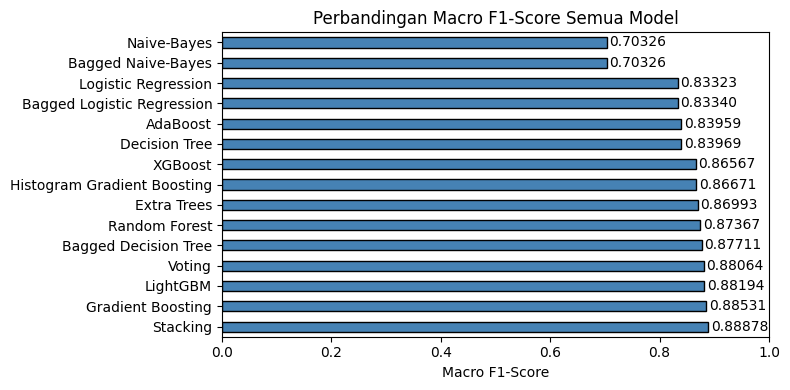

In [ ]:
# Tabel perbandingan
results_df = (
  pd.DataFrame.from_dict(results, orient='index', columns=['Macro F1-Score'])
  .sort_values('Macro F1-Score', ascending=False)
)
print(results_df.to_string())

# Bar chart
plt.figure(figsize=(8, 4))
results_df['Macro F1-Score'].plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Macro F1-Score')
plt.title('Perbandingan Macro F1-Score Semua Model')
plt.xlim(0, 1)
for i, v in enumerate(results_df['Macro F1-Score']):
    plt.text(v + 0.005, i, f'{v:.5f}', va='center')
plt.tight_layout()
plt.show()

**Kesimpulan Perbandingan:**  


Berdasarkan metrik *Macro F1-Score*, model yang terbaik adalah model Stacking dengan *Macro F1-Score* bernilai $0.88878$. Metode Stacking menggabungkan prediksi dari beberapa algoritma yang berbeda pada level dasar. Kita sudah memilih algoritma dengan hasil yang lumayan baik. Kemudian, prediksi-prediksi dari level dasar dipelajari kembali oleh sebuah *meta-estimator* di level selanjutnya untuk menghasilkan prediksi akhir yang lebih cerdas. Dengan kata lain, Stacking berhasil menutupi kelemahan satu model dengan model lainnya yang lebih kuat, sehingga menghasilkan kinerja gabungan yang lebih baik lagi.

Trade-off antara akurasi, kecepatan training, dan interpretabilitas.
- Akurasi: Model ensemble konsisten berada pada peringkat atas. Sebaliknya, model tunggal seperti Naive- Bayes atau Logistic Regression memiliki kinerja terendah.

- Kecepatan Training: Stacking biasanya membutuhkan waktu training lambat karena harus melatih banyak model dasar dan *meta-learning*. Model Gradient Boosting melatih pohon secara sekuensial sehingga memakan waktu. Random Forest dan metode Bagging lainnya melatih setiap model dasarnya secara independen dan paralel, sehingga secara waktu lebih efisien. Adapun model sederhana seperti Logistic Regression dan Naive-Bayes sangat cepat dilatih.

- Interpretabilitas: Stacking, Gradient Boosting, dan Random Forest adalah model *Black-Box* yang sulit untuk menjelaskan mengapa pengajuan nasabah ditolak hanya dengan melihat struktur modelnya. Akan tetapi, model dengan skor rendah seperti Decision Tree atau Logistic Regression bersifat *White-Box*yang bisa dijelaskan seperti halnya aturan tradisional.

---
## 4. Error Analysis

> **Tujuan:** Memahami pola kegagalan model dan menemukan peluang perbaikan.

### 4.1 Confusion Matrix

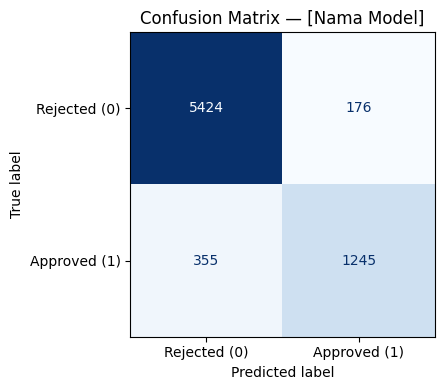

In [ ]:
best_model   = stacking_final_model  # TODO: ganti dengan model terbaik Anda
y_pred_best  = best_model.predict(X_val)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred_best),
    display_labels=['Rejected (0)', 'Approved (1)']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Stacking')  # TODO: isi nama model
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.base import BaseEstimator, ClassifierMixin

base_estimators = [
  ('Bagged Decision Tree',  base_models['Decision Tree']),
  ('LightGBM',  lgb_model),
  ('Gradient Boosting', gb_model),
]

meta_learner = LogisticRegression()

stacking_prob_model = StackingClassifier(
  estimators=base_estimators,
  final_estimator=meta_learner,
  cv=10,
  passthrough = True,
  n_jobs=-1,
)

stacking_final_model = ThresholdEnsemble(
    ensemble_model=stacking_prob_model,
    threshold=0.53
)

stacking_final_model.fit(X_train, y_train)

results['Stacking'] = evaluate_model(stacking_final_model, X_val, y_val, 'Stacking')

  Stacking
              precision    recall  f1-score   support

Rejected (0)       0.94      0.97      0.95      5600
Approved (1)       0.88      0.78      0.82      1600

    accuracy                           0.93      7200
   macro avg       0.91      0.87      0.89      7200
weighted avg       0.92      0.93      0.92      7200

>>> Macro F1-Score: 0.8888



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.base import BaseEstimator, ClassifierMixin

base_estimators = [
  ('Bagged Decision Tree',  base_models['Decision Tree']),
  ('LightGBM',  lgb_model),
  ('Gradient Boosting', gb_model),
]

meta_learner = LogisticRegression()

stacking_prob_model = StackingClassifier(
  estimators=base_estimators,
  final_estimator=meta_learner,
  cv=10,
  passthrough = True,
  n_jobs=-1,
)

stacking_final_model = ThresholdEnsemble(
    ensemble_model=stacking_prob_model,
    threshold=0.53
)

stacking_final_model.fit(X_train, y_train)

results['Stacking'] = evaluate_model(stacking_final_model, X_val, y_val, 'Stacking')

  Stacking
              precision    recall  f1-score   support

Rejected (0)       0.94      0.97      0.95      5600
Approved (1)       0.88      0.78      0.82      1600

    accuracy                           0.93      7200
   macro avg       0.91      0.87      0.89      7200
weighted avg       0.92      0.93      0.92      7200

>>> Macro F1-Score: 0.8888



**Analisis Confusion Matrix:**  

Asumsikan bahwa kelas Positif adalah kelas 1/*approval* dan kelas Negatif adalah kelas 0/*rejected*. Berdasarkan *Confusion Matrix* untuk model Stacking, diperoleh $\text{FP}=176$ dan $\text{FN}=355$. Nilai FP menunjukkan jumlah nasabah yang sebenarnya harus ditolak pinjamannya, tetapi model memprediksi mereka menjadi disetujui. Adapun nilai FN menunjukkan jumlah nasabah yang sebenarnya layak disetujui pinjamannya, tetapi model justru memprediksi mereka menjadi ditolak.

Dalam dunia perbankan, terutrama *loan approval*, FP umumnya lebih merugikan dibandingkan FN. Hal ini dikarenakan peluang tinggi akan terjadinya risiko kredit macet yang menyebabkan kehilangan modal atau pendapatan kreditur atas bunga pinjaman. Adapun dampak dari FN yaitu kreditur kehilangan potensi pendapatan bunga atas pinjaman dan mengurangi tingkat kepuasan pelanggan. Akan tetapi, kreditur tidak akan kehilangan uang modal sama sekali.



### 4.2 Analisis Sampel yang Salah Diklasifikasikan

In [ ]:
# Snippet: membuat dataframe error
# -------------------------------------------------------
y_val_arr  = y_val.reset_index(drop=True)
X_val_arr  = X_val.reset_index(drop=True)
pred_arr   = pd.Series(y_pred_best, name='y_pred')

error_mask = y_val_arr != pred_arr
error_df = X_val_arr[error_mask].copy()
error_df['y_true'] = y_val_arr[error_mask].values
error_df['y_pred'] = pred_arr[error_mask].values

print(f"Total error: {len(error_df)} / {len(y_val)} sampel ({len(error_df)/len(y_val)*100:.1f}%)")
# -------------------------------------------------------

# TODO: Analisis error — cari pola
# Pertanyaan panduan:
#   - Apakah error terkonsentrasi pada credit_score atau income tertentu?
#   - Apakah previous_loan_defaults berkorelasi dengan jenis error?
#   - Apakah ada home_ownership type yang lebih sering salah?


Total error: 531 / 7200 sampel (7.4%)


### 4.3 Feature Importance

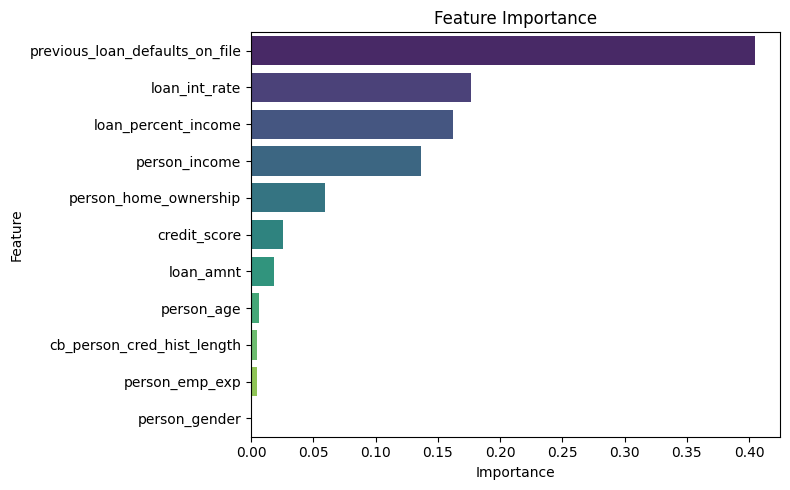

In [ ]:
# Snippet: feature importance dari tree-based model
# -------------------------------------------------------
model_with_fi = gb_model

importance_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': model_with_fi.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()
# -------------------------------------------------------

# TODO: Visualisasikan feature importance


**Analisis Feature Importance:**  


Berdasarkan grafik *Feature Importance*, kita dapat menganalisis fitur-fitur yang paling memengaruhi keputusan model dalam menentukan status *loan*. Model ini sangat bergantung pada empat fitur utama ini, yakni `previous_loan_defaults_on_file` kira-kira $40\%$, `loan_int_rate` kira-kira $17\%$, `loan_percent_income` kira-kira $16\%$, dan `person_income` kira-kira $13\%$. Secara kumulatif, keempat fitur tersebut memengaruhi model sekitar $86\%$ dari hasil prediksi. Hal ini tentunya masuk akal secara bisnis. Fitur `previous_loan_defaults_on_file` menjadi indikator utama. Jika seorang nasabah memiliki riwayat gagal bayar di masa lalu, risiko mereka untuk kembali gagal bayar sangatlah tinggi. Lalu fitur `loan_percent_income` dan `person_income` mengukur kapasitas finansial nasabah untuk mencicil pinjaman. Jika bagian utang terlalu membebani pendapatan, kemungkinan macet kredit sangat besar. Terakhir fitur `loan_int_rate` yang biasanya sudah disesuaikan dengan profil risiko nasabah sejak awal. Suku bunga yang tinggi akan memperberat cicilan, kemungkinan meningkatkan peluang gagal bayar.

Sebaliknya, fitur dengan kepentingan sangat rendah, di bawah $1\%$ di antaranya `person_age`, `cb_person_cred_hist_length`, `person_emp_exp`, dan `person_gender`. Fitur-fitur ini bisa dihapus sehingga menyederhanakan model, mempercepat waktu *training*, dan mencegah *overfitting*.

### 4.4 Kesimpulan Error Analysis

Pada model terbaik yang dipilih yaitu model Stacking, diperoleh 531 sampel atau $7.4\%$ yang salah diklasifikasikan, dengan $\text{FP}=176$ dan $\text{FN}=355$. Dari sini, dapat ditarik kesimpulan bahwa model sulit untuk mengklasifikasikan kelas *approved* dibandingkan kelas *rejected*.

---
## 5. Submisi Kaggle

> ⚠️ **PENTING:**
> - Jangan gunakan `sample_submission.csv` sebagai submisi utama.
> - Pastikan hasil prediksi **reproducible** dari notebook ini.
> - Format: kolom `person_id` dan `loan_status`.

In [ ]:
final_model = stacking_final_model  # TODO: model dengan Macro F1 tertinggi

test_predictions = final_model.predict(X_test_final)

submission = pd.DataFrame({
  'person_id':   test_df[ID_COL],
  'loan_status': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"Saved! Shape: {submission.shape}")
print(f"Distribusi prediksi:\n{submission['loan_status'].value_counts()}")
submission.head(10)

Saved! Shape: (9000, 2)
Distribusi prediksi:
loan_status
0    7161
1    1839
Name: count, dtype: int64


,person_id,loan_status
0,10751,0
1,17513,0
2,17071,0
3,35944,0
4,15750,1
5,20533,1
6,9858,0
7,17445,0
8,18043,0
9,11046,0


**Catatan Submisi:**
| | |
|---|---|
| Model final | *Stacking* |
| Macro F1 — Validation Set | *0.88878* |
| Macro F1 — Kaggle Public LB | *0.89565* |
| Macro F1 — Kaggle Private LB | *0.89359* |

---
## 6. Kesimpulan Keseluruhan

Berdasarkan serangkaian proses *Exploratory Data Analysis (EDA)*, penerapan model-model *machine learning* dengan *ensemble methods*, dan evaluasi performa model yang telah dilakukan, dapat diambil kesimpulan sebagai berikut.
1. Model Stacking menjadi model *ensemble* terbaik dengan nilai *Macro F1-Score* tertinggi, yakni $0.88878$. Pada model ini dipilih *base estimators* berupa Decision Tree dengan Bagging, Light Gradient Boosting, dan Gradient Boosting.  Meta-learner yang digunakan adalah Logistic Regression. Secara umum, penerapan metode *ensemble* berhasil mengatasi kelemahan dari model dasar, sehingga menghasilkan performa model yang lebih baik dalam mengklasifikasikan kelas.
2. Beberapa *insight* dari proses EDA yakni fitur riwayat gagal bayar merupakan prediktor yang memiliki korelasi terkuat dengan status *loan*. Selain itu, beban utang dan suku bunga juga menjadi indikator penting dalam menentukan status *loan*. Lalu ditemukan korelasi tinggi antara usia, pengalaman kerja, dan panjang riwayat kredit. Selain itu, fitur seperti gender merupaka fitur *noise* yang tidak memberikan pengaruh terhadap status *loan*. Terdapat data pencilan yang tidak masuk akal, seperti usia $144$ tahun dan pengalaman kerja selama $123$ tahun.
3. Model memiliki tingkat kesalahan yang relatif terkendali, yaitu sekitar $7.4\%$ dari total data validasi. Secara perilaku, model cenderung lebih banyak menghasilkan False Negative atau menolak nasabah yang seharusnya layak diberi pinjaman dibandingkan False Positive atau meloloskan nasabah yang layak ditolak.

Adapun saran untuk peningkatan di antaranya sebagai berikut.
1. Menghapus atau mengimputasi baris data yang memiliki nilai pencilan ekstrem seperti usia dan pengalaman kerja yang mustahil agar batas keputusan model menjadi lebih tajam.
2. Membuang fitur *redundant* dan fitur dengan skor *importance* sangat rendah seperti gender dan panjang riwayat kredit untuk menyederhanakan *pipeline*, mencegah *overfitting*, dan mempercepat waktu komputasi.
3. Menggunakan dataset lain yang memiliki fitur yang penting untuk *loan approval* seperti jenis pekerjaan nasabah yang menggambarkan penghasilan nasabah apakah stabil dalam jangka waktu bulanan atau tahunan yang cukup lama.